<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل ششم: رگرسیون خطی ساده</h2>
</div>


<div dir="rtl" style="text-align: right; line-height: 1.8;">

# مثال عملی رگرسیون خطی برای شمارش رکوردهای ثبت‌شده

هر ردیف این مثال، تعداد گزارش‌های یک روز، یک منطقه و یک ساعت را نشان می‌دهد. مانند فایل ارسالی، فقط ترکیب‌هایی وارد جدول می‌شوند که دست‌کم یک رکورد دارند؛ بنابراین برآورد، مشروط به وجود گزارش است. این مدل خطی چندمتغیره است و ادامهٔ آموزشیِ رگرسیون سادهٔ فصل محسوب می‌شود.

</div>


<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>


In [6]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## ۱. خواندن تاریخ و ساخت جدول شمارش

فایل از سال ۲۰۲۰ به بعد بررسی می‌شود. نبودن یک ترکیب روز و منطقه و ساعت، در این فایل به‌تنهایی اثبات نمی‌کند که شمار واقعی جرم صفر بوده است.

</div>


In [7]:
# خواندن تاریخ و ساخت جدول شمارش
df = pd.read_csv(DATA / "Crime_data from 2001 to present.csv",
                 usecols=["Date", "District"])
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M")
df = df.loc[df["Date"].dt.year.ge(2020)].dropna().copy()
df["Day"] = df["Date"].dt.normalize()
df["Hour"] = df["Date"].dt.hour
df["District"] = df["District"].astype(int).astype(str)
# هر ردیف خروجی یک ترکیب مشاهده‌شده است.
counts = df.groupby(["Day", "District", "Hour"]).size()
counts = counts.rename("Crime_Count").reset_index().sort_values("Day")
display(counts.head())

,Day,District,Hour,Crime_Count
0,2020-01-01,10,0,4
21,2020-01-01,25,12,1
22,2020-01-01,3,0,3
23,2020-01-01,4,0,3
24,2020-01-01,4,12,1


<div dir="rtl" align="right">

## ۲. تقسیم بر اساس روزهای کامل

۸۰ درصد نخستِ روزها برای آموزش و روزهای بعدی برای آزمون‌اند. یک روز بین دو مجموعه تقسیم نمی‌شود.

</div>


In [8]:
# تقسیم بر اساس روزهای کامل
days = counts["Day"].drop_duplicates().sort_values().to_numpy()
cutoff = pd.Timestamp(days[int(0.8 * len(days))])
train = counts.loc[counts["Day"] < cutoff]
test = counts.loc[counts["Day"] >= cutoff]
features = ["Hour", "District"]
X_train, y_train = train[features], train["Crime_Count"]
X_test, y_test = test[features], test["Crime_Count"]
assert train["Day"].max() < test["Day"].min()
print("Train:", len(train), "Test:", len(test), "Cutoff:", cutoff.date())

Train: 228084 Test: 113524 Cutoff: 2023-08-20


<div dir="rtl" align="right">

## ۳. آموزش و ارزیابی

منطقه یک دسته است و با کدگذاری صفر و یک وارد مدل می‌شود. مدل خطی ممکن است عدد اعشاری یا منفی تولید کند؛ این عدد را به‌عنوان برآورد عملیاتیِ جرم معرفی نمی‌کنیم.

</div>


In [9]:
# آموزش و ارزیابی
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

prepare = ColumnTransformer([
    ("district", OneHotEncoder(drop="first", handle_unknown="ignore"),
     ["District"]),
    ("hour", "passthrough", ["Hour"])
])
model = make_pipeline(prepare, LinearRegression())
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2:", r2_score(y_test, prediction))

MAE: 0.8735189885998014
RMSE: 1.2079663970872192
R2: -0.06480821572004913


<div dir="rtl" align="right">

## ۴. خواندن نتیجه و یک ورودی تازه

در نمودار، فقط ۱۰۰ ردیف اول آزمون نمایش داده می‌شود. ورودی تازه با نام واقعی ستون‌ها ساخته می‌شود تا شمارهٔ منطقه اشتباه به ستون دیگری نگاشت نشود.

</div>


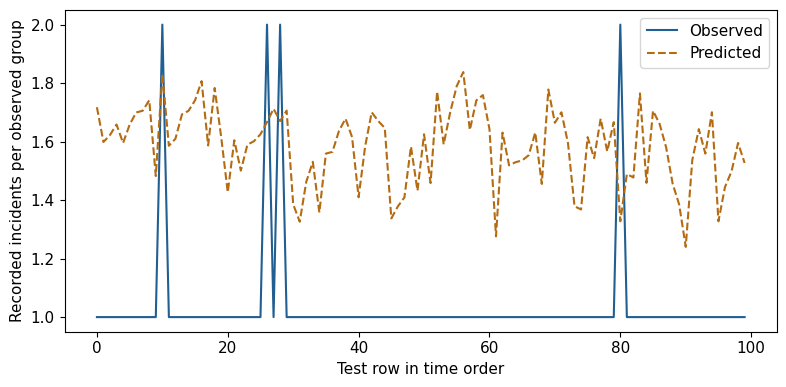

Conditional estimate: 1.6549146342035808


,Coefficient
district__District_10,-0.074280
district__District_11,0.176723
district__District_12,0.057015
district__District_14,-0.203518
district__District_15,-0.150682
district__District_16,-0.130066
district__District_17,-0.273731
district__District_18,0.029385
district__District_19,-0.021947
district__District_2,-0.028771


In [10]:
# خواندن نتیجه و یک ورودی تازه
n = min(100, len(y_test))
plt.plot(y_test.to_numpy()[:n], label="Observed", color="#215e91")
plt.plot(prediction[:n], "--", label="Predicted", color="#b46b12")
plt.xlabel("Test row in time order")
plt.ylabel("Recorded incidents per observed group")
plt.legend()
plt.tight_layout()
plt.show()
new_case = pd.DataFrame({"Hour": [22], "District": ["3"]})
print("Conditional estimate:", model.predict(new_case)[0])
coefficients = pd.Series(model[-1].coef_,
                         index=model[0].get_feature_names_out())
display(coefficients.rename("Coefficient").to_frame())

<div dir="rtl" align="right">

## نکتهٔ پایانی
در این اجرا، MAE حدود ۰٫۸۷۴، RMSE حدود ۱٫۲۰۸ و R² حدود منفی ۰٫۰۶۵ است. R² منفی یعنی مجموع مربع خطا از پیش‌بینیِ ثابتِ میانگین هدف آزمون بیشتر شده است. مدل در این تقسیم عملکرد قوی نشان نمی‌دهد.

MAE و RMSE بر حسب شمار رکورد در هر ترکیب مشاهده‌شده هستند. R² سهمی از صحت طبقه‌بندی نیست و می‌تواند منفی شود. این نتیجه فقط روی بازهٔ آزمون همین فایل سنجیده شده است.

</div>


<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>
